In [1]:
import arcgis
from arcgis.gis import GIS
gis = GIS('https://dev003246.esri.com/portal', 'admin', 'esri.agp')

In [2]:
gis.properties.helperServices.rasterAnalytics.url

'https://dev003248.esri.com/rax/rest/services/System/RasterAnalysisTools/GPServer'

In [2]:
arcgis.raster.analytics.is_supported()

True

<Item title:"ImgSrv_Landast_Montana2015" type:Image Service owner:admin>
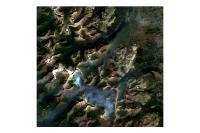

In [3]:
imglyr = gis.content.search('Landsat Montana2015', 'image layer')[0]
imglyr

In [4]:
res = arcgis.raster.summarize_raster_within(imglyr, imglyr)

In [5]:
res

<Item title:"SummarizeRasterWithin_L1O0Q4" type:Image Service owner:admin>

In [6]:
m = gis.map('Montana')
m

In [7]:
m.add_layer(res)

In [4]:
import pandas as pd
df = pd.read_csv('data/chennai-rainfall.csv')
df.head()

,WEATHER STATION,LOCATION,RAINFALL
0,TAMBARAM,"TAMBARAM, TAMIL NADU",49
1,CHEMBARABAKKAM,"CHEMBARABAKKAM, TAMIL NADU",47
2,MARAKKANAM,"MARAKKANAM, TAMIL NADU",42
3,CHENGALPATTU,"CHENGALPATTU, TAMIL NADU",39
4,PONNERI,"PONNERI, TAMIL NADU",39


In [5]:
m2 = gis.map("Tamil Nadu", zoomlevel = 7)
m2

In [6]:
rainfall = gis.content.import_data(df, {"Address" : "LOCATION"})

In [7]:
m2.add_layer(rainfall, { "renderer":"ClassedSizeRenderer", "field_name":"RAINFALL" })

In [8]:
interpolated_rf = arcgis.raster.interpolate_points(rainfall, 'RAINFALL')

In [9]:
interpolated_rf

{'output_error_raster': '',
 'output_raster': <Item title:"InterpolatePoints_K9CGAE" type:Image Service owner:admin>,
 'process_info': ['{"messageCode": "RA_120101", "message": "The following table contains cross validation statistics:", "params": {}, "style": "<b></b><br></br>"}',
  '{"messageCode": "RA_120102", "message": ["Mean Error", "${meanError}"], "params": {"meanError": "-0.620751466423128"}, "style": "<table style=\'width: 250px;margin-left: 2.5em;\'><tbody><tr><td></td><td style=\'float:right\'></td></tr>"}',
  '{"messageCode": "RA_120103", "message": ["Root Mean Square", "${rootMeanSquare}"], "params": {"rootMeanSquare": "8.93357774324515"}, "style": "<tr><td></td><td style=\'float: right;\'></td></tr>"}',
  '{"messageCode": "RA_120104", "message": ["Average Standard", "${averageStandard}"], "params": {"averageStandard": "8.93728791581937"}, "style": "<tr><td></td><td style=\'float: right;\'></td></tr>"}',
  '{"messageCode": "RA_120105", "message": ["Mean Standardized", "${

In [10]:
interpolated_rf['output_raster']

<Item title:"InterpolatePoints_K9CGAE" type:Image Service owner:admin>

In [11]:
m2.add_layer(interpolated_rf['output_raster'])

In [15]:
itm = gis.content.get('c7c0ca17440f4816b32c85c476da61e6')

In [16]:
m2.add_layer(itm)

In [10]:
m2.add_layer(interpolated_rf)

In [4]:
m3 = gis.map('Chennai')
m3

In [13]:
m3.add_layer(interpolated_rf)

In [14]:
interpolated_rf.url

'http://dev003248.esri.com/rax/rest/services/Hosted/InterpolatePoints_LJFHKD/ImageServer'

In [14]:
interpolated_rf2 = arcgis.features.analyze_patterns.interpolate_points(rainfall, 'RAINFALL', output_prediction_error=True)

In [15]:
interpolated_rf2

{'predicted_point_layer': <FeatureCollection>,
 'prediction_error': <FeatureCollection>,
 'result_layer': <FeatureCollection>}

In [7]:
m2.add_layer(interpolated_rf2['result_layer'])

In [34]:
m2.add_layer(interpolated_rf2['result_layer'])

In [9]:
sep16 = gis.content.search('sep16', 'Feature Collection')[0]

<Item title:"sep16" type:Feature Collection owner:admin>
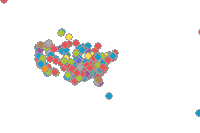

In [10]:
sep16

In [11]:
res = arcgis.raster.analytics.calculate_density(sep16)

In [12]:
res

<Item title:"CalculateDensity_TS916R" type:Image Service owner:admin>

In [13]:
m = gis.map('USA')
m

In [14]:
m.add_layer(res)